## Flujo de trabajo
**1. Tema de investigación: panorama turístico en Oaxaca.**
* Preguntas:
    * ¿Cómo se ha desarrollado la industria hotelera en el estado?
    * ¿El crecimiento en su oferta tiene eco en la demanda?
    * ¿Cómo se compone principalmente este mercado?
    * Retos y problemáticas del crecimiento turístico.
2. **Data ingestion.**
3. **Data Wrangling.**
4. **EDA Data Exploration.**
5. **Visualización e interpretación de los datos.**
6. **Conclusiones.**

In [2]:
import io
import requests
import pandas as pd
import numpy as np
import math
from data_profiling import ProfileReport
from IPython.display import FileLink
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

%matplotlib inline

In [3]:
# Extracción de datos (URL de la fuente pública gubernamental)
url_datos = "https://repodatos.atdt.gob.mx/s_turismo/ocupacion_hotelera/Base70centros.csv"

def obtener_dataframe_remoto(url: str) -> pd.DataFrame:
    """Descarga un archivo CSV desde una URL directamente a la memoria RAM
    y lo convierte en un DataFrame de Pandas listo para su análisis.
    
    Parámetros:
    url (str): enlace directo del archivo gubernamental.
    
    Retorna:
    pd.DataFrame: Objeto con los datos estructurados en memoria.
    """
    try:
        print("Conectando con el servidor remoto...")
        
        # Realizamos la solicitud GET para obtener el contenido binario del archivo
        respuesta = requests.get(url, timeout=30)
        respuesta.raise_for_status()  # Verificar si la solicitud fue exitosa
        
        print("Datos recibidos. Convirtiendo a DataFrame en memoria...")
        
        # io.BytesIO convierte los bytes recibidos en un flujo binario que Pandas puede leer como si fuera un archivo real
        flujo_datos = io.BytesIO(respuesta.content)
        
        # Leemos el flujo binario directamente con Pandas
        df = pd.read_csv(flujo_datos, sep = "\t", encoding="utf-8")
        
        print("Proceso completado con éxito. Objeto listo para análisis.")
        return df

    except requests.exceptions.HTTPError as http_err:
        print(f"Error HTTP al intentar acceder al servidor: {http_err}")
        raise
    except requests.Timeout as timeout_err:
        print(f"Error de tiempo de espera al intentar conectar: {timeout_err}")
        raise
    except requests.RequestException as req_err:
        print(f"Error general en la solicitud de datos: {req_err}")
        raise

# --- EJECUCIÓN Y ALMACENAMIENTO EN VARIABLE ---
# Llamamos a la función y guardamos el dataset en la variable 'df_turismo'
df_turismo = obtener_dataframe_remoto(url_datos)



Conectando con el servidor remoto...
Datos recibidos. Convirtiendo a DataFrame en memoria...
Proceso completado con éxito. Objeto listo para análisis.


In [4]:
#Observamos nuestro dataset
df_turismo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31147 entries, 0 to 31146
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   anio                            31147 non-null  int64  
 1   mes                             31147 non-null  int64  
 2   tipo_centro                     31147 non-null  object 
 3   subtipo_centro                  31147 non-null  object 
 4   centro                          31147 non-null  object 
 5   categoria                       31147 non-null  object 
 6   cuartos_disponibles             31147 non-null  int64  
 7   cuartos_ocupados_no_residentes  31147 non-null  int64  
 8   cuartos_ocupados_residentes     31147 non-null  int64  
 9   llegada_turistas_no_residentes  31147 non-null  int64  
 10  llegada_turistas_residentes     31147 non-null  int64  
 11  turistas_noche_no_residentes    31147 non-null  int64  
 12  turistas_noche_residentes       

In [5]:
#Creamos un reporte detallado de nuestro dataset para encontrar anomalías
perfil_data = ProfileReport(df_turismo, title = "Reporte del dataset", explorative= True)

#Guardamos en un html nuestro reporte
perfil_data.to_file("Reporte.html")
FileLink("Reporte.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 218.54it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\USER\Downloads\proyecto-portafolio\Reporte.html

El html es un reporte detallado de cada una de las variables dentro del dataset: valores faltantes, duplicados, únicos, sus totales y tipos, además de un desglose por cada variable y una primera forma de presentar las correlaciones existentes en el dataset.
Derivado del reporte se observa que en el dataset no existen valores nulos ni duplicados, aunque, como se verá, existe una gran cantidad de valores 0.

Data wrangling

Limpieza y manipulación de datos categóricos

In [5]:
#Cambiamos el tipo de dato de las varaibles categoricas
#Creamos una copia del dataset para la limpieza
df_turismo_clean = df_turismo.copy()

#Estandarizamos y normalizamos los nombres de las coumnas
df_turismo_clean = df_turismo_clean.rename(columns={"anio": "año"})

#Definimos nuestras columnas categóricas
columnas_categoricas = ["tipo_centro", "subtipo_centro", "centro", "categoria"]

#Limpiamos espacios vacío en nuestros registros
df_turismo_clean[columnas_categoricas] = df_turismo_clean[columnas_categoricas].apply(lambda x: x.str.strip())

#Cambiamos el tipo de dato 
df_turismo_clean[columnas_categoricas] = df_turismo_clean[columnas_categoricas].astype("category")


In [6]:
df_turismo_clean.head()

,año,mes,tipo_centro,subtipo_centro,centro,categoria,cuartos_disponibles,cuartos_ocupados_no_residentes,cuartos_ocupados_residentes,llegada_turistas_no_residentes,llegada_turistas_residentes,turistas_noche_no_residentes,turistas_noche_residentes
0,2016,1,Centros de Playa,Integralmente Planeados,Ixtapa - Zihuatanejo,3 estrellas,10819,5333,2421,3888,2023,10116,5175.0
1,2016,1,Centros de Playa,Integralmente Planeados,Ixtapa - Zihuatanejo,4 estrellas,45090,8114,29303,3941,21399,15301,63565.0
2,2016,1,Centros de Playa,Integralmente Planeados,Ixtapa - Zihuatanejo,5 estrellas,105015,32190,47030,12240,44790,64356,109299.0
3,2016,1,Centros de Playa,Integralmente Planeados,Bahías de Huatulco,2 estrellas,5549,0,2571,0,4816,0,6320.0
4,2016,1,Centros de Playa,Integralmente Planeados,Bahías de Huatulco,3 estrellas,12896,0,4360,0,8560,0,11464.0


In [7]:
#Creamos nuestra variable datetime (Fecha)
df_turismo_clean["fecha"] = pd.to_datetime(
    {
        "year": df_turismo_clean["año"],
        "month": df_turismo_clean["mes"],
        "day": 1
    }
)

#Revisamos nuestro dataset
df_turismo_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31147 entries, 0 to 31146
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   año                             31147 non-null  int64         
 1   mes                             31147 non-null  int64         
 2   tipo_centro                     31147 non-null  category      
 3   subtipo_centro                  31147 non-null  category      
 4   centro                          31147 non-null  category      
 5   categoria                       31147 non-null  category      
 6   cuartos_disponibles             31147 non-null  int64         
 7   cuartos_ocupados_no_residentes  31147 non-null  int64         
 8   cuartos_ocupados_residentes     31147 non-null  int64         
 9   llegada_turistas_no_residentes  31147 non-null  int64         
 10  llegada_turistas_residentes     31147 non-null  int64         
 11  tu

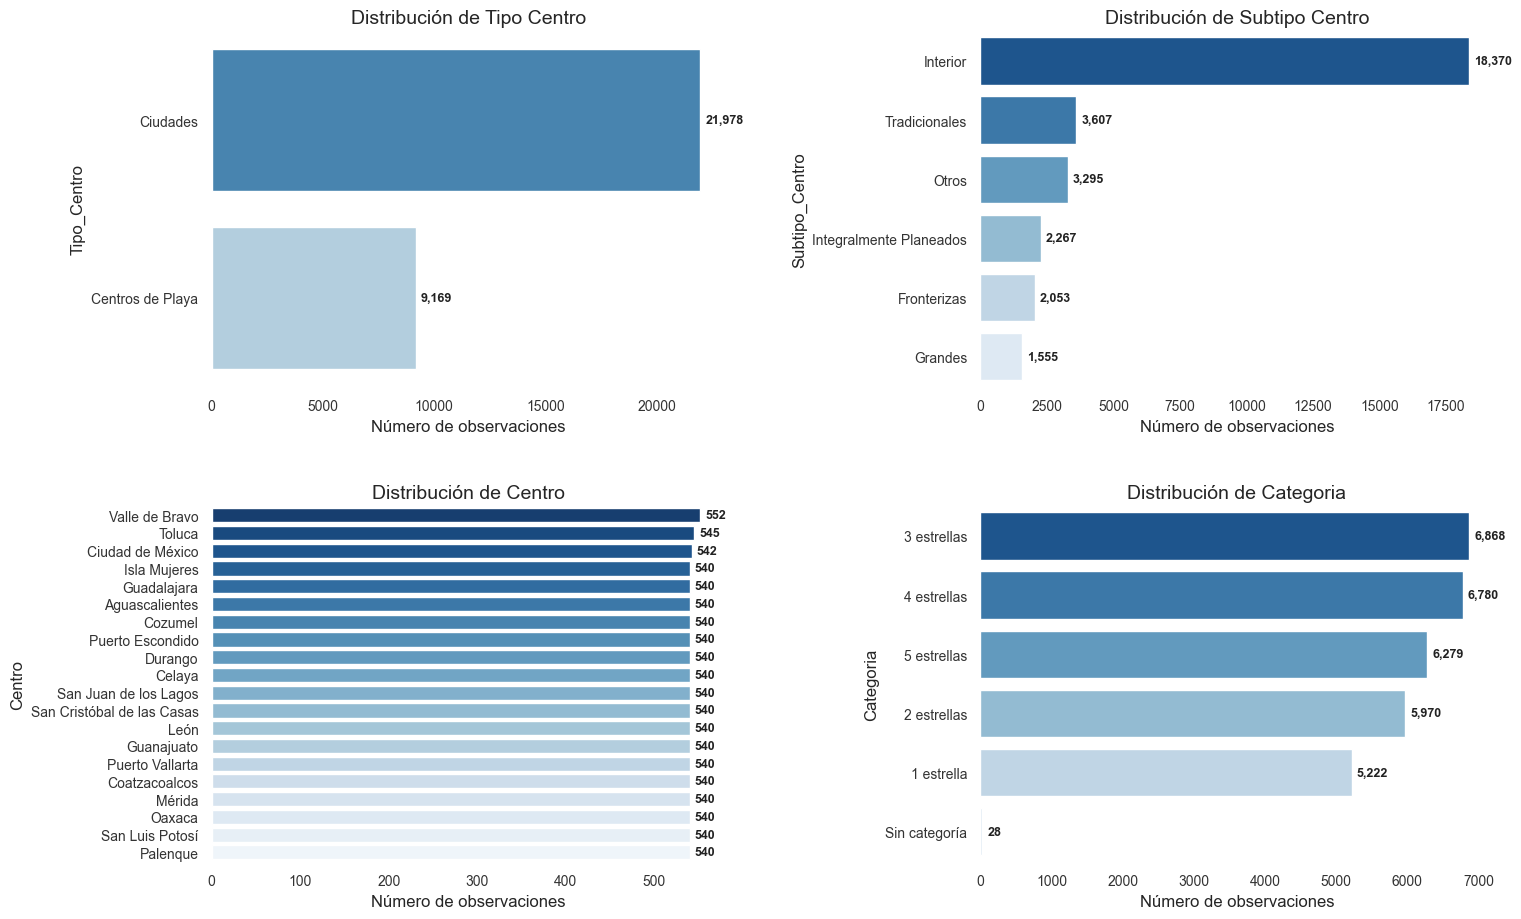

In [8]:
#creamos una función para graficar las variables categoricas para observar su distribución
def plot_categorica(df: pd.DataFrame, columnas: list, top = 10):
    """Genera un único lienzo con subgráficas de barras para las variables categóricas.
    Parámetros:
    df (pd.DataFrame): DataFrame que contiene los datos.
    columnas (list): Lista de columnas categóricas a graficar.
    top (int): Número de categorías máximas a mostrar por gráfica.
    """
    
    #Configuración estética de los gráficos
    sns.set_theme(style = "white")
    plt.rcParams["font.family"] = "sans-serif"

    #Calculamos las filas y columnas para le lienzo
    num_columnas_grid = 2
    num_filas_grid = math.ceil(len(columnas) / num_columnas_grid)

    #Creamos el lienzo
    fig, axes = plt.subplots(
        nrows = num_filas_grid,
        ncols = num_columnas_grid,
        figsize = (16, 5 * num_filas_grid)
    )

    #Iteramos sobre las columnas y los ejes para graficar
    axes = axes.flatten()  # Aplanamos los ejes para iterar fácilmente

    for idx, col in enumerate(columnas):
        ax = axes[idx]

        #Obtenemos el top de los datos
        conteo = df[col].astype(str).value_counts().nlargest(top) #Convertimos a string para evitar problemas con tipos category

        #Gráfico de barras horizontal
        sns.barplot(x = conteo.values,
                    y = conteo.index,
                    ax = ax,
                    palette = "Blues_r",
                    hue = conteo.index,
                    legend = False
                    )
        #Configuración de títulos y etiquetas
        ax.set_title(f'Distribución de {col.title().replace("_", " ")}', fontsize = 14)
        ax.set_xlabel("Número de observaciones", fontsize = 12)
        ax.set_ylabel(col.title(), fontsize = 12)
        ax.tick_params(labelsize = 10, colors = "#333333")

        #Colocamos el conteo de observaciones a cada categoría
        max_valor = max(conteo.values) if not conteo.empty else 1
        for i,v in enumerate(conteo.values):
            ax.text(
                v + (max_valor * 0.01),
                i,
                f"{v:,}",
                color="#222222",
                va="center",
                fontsize=9,
                weight="semibold",
            )
        #Removemos bordes
        sns.despine(ax = ax, left = True, bottom = True)
    plt.tight_layout(pad = 3.0)
    plt.show()

# Definición de variables
columnas_categoricas = ["tipo_centro", "subtipo_centro", "centro", "categoria"]

# Ejecutamos nuestra función para graficar
plot_categorica(df_turismo_clean, columnas_categoricas,20)

Limpieza de variables numéricas

Siguiendo los resultados del reporte con data_profilin, la revisión de valores faltantes arroja un conteo cero para todas las columnas del dataset, sin embargo, debe contemplarce el uso del valor 0 como valor de registro para los datos. Por tanto, una observación con 0 cuartos por noche es un dato relevante.

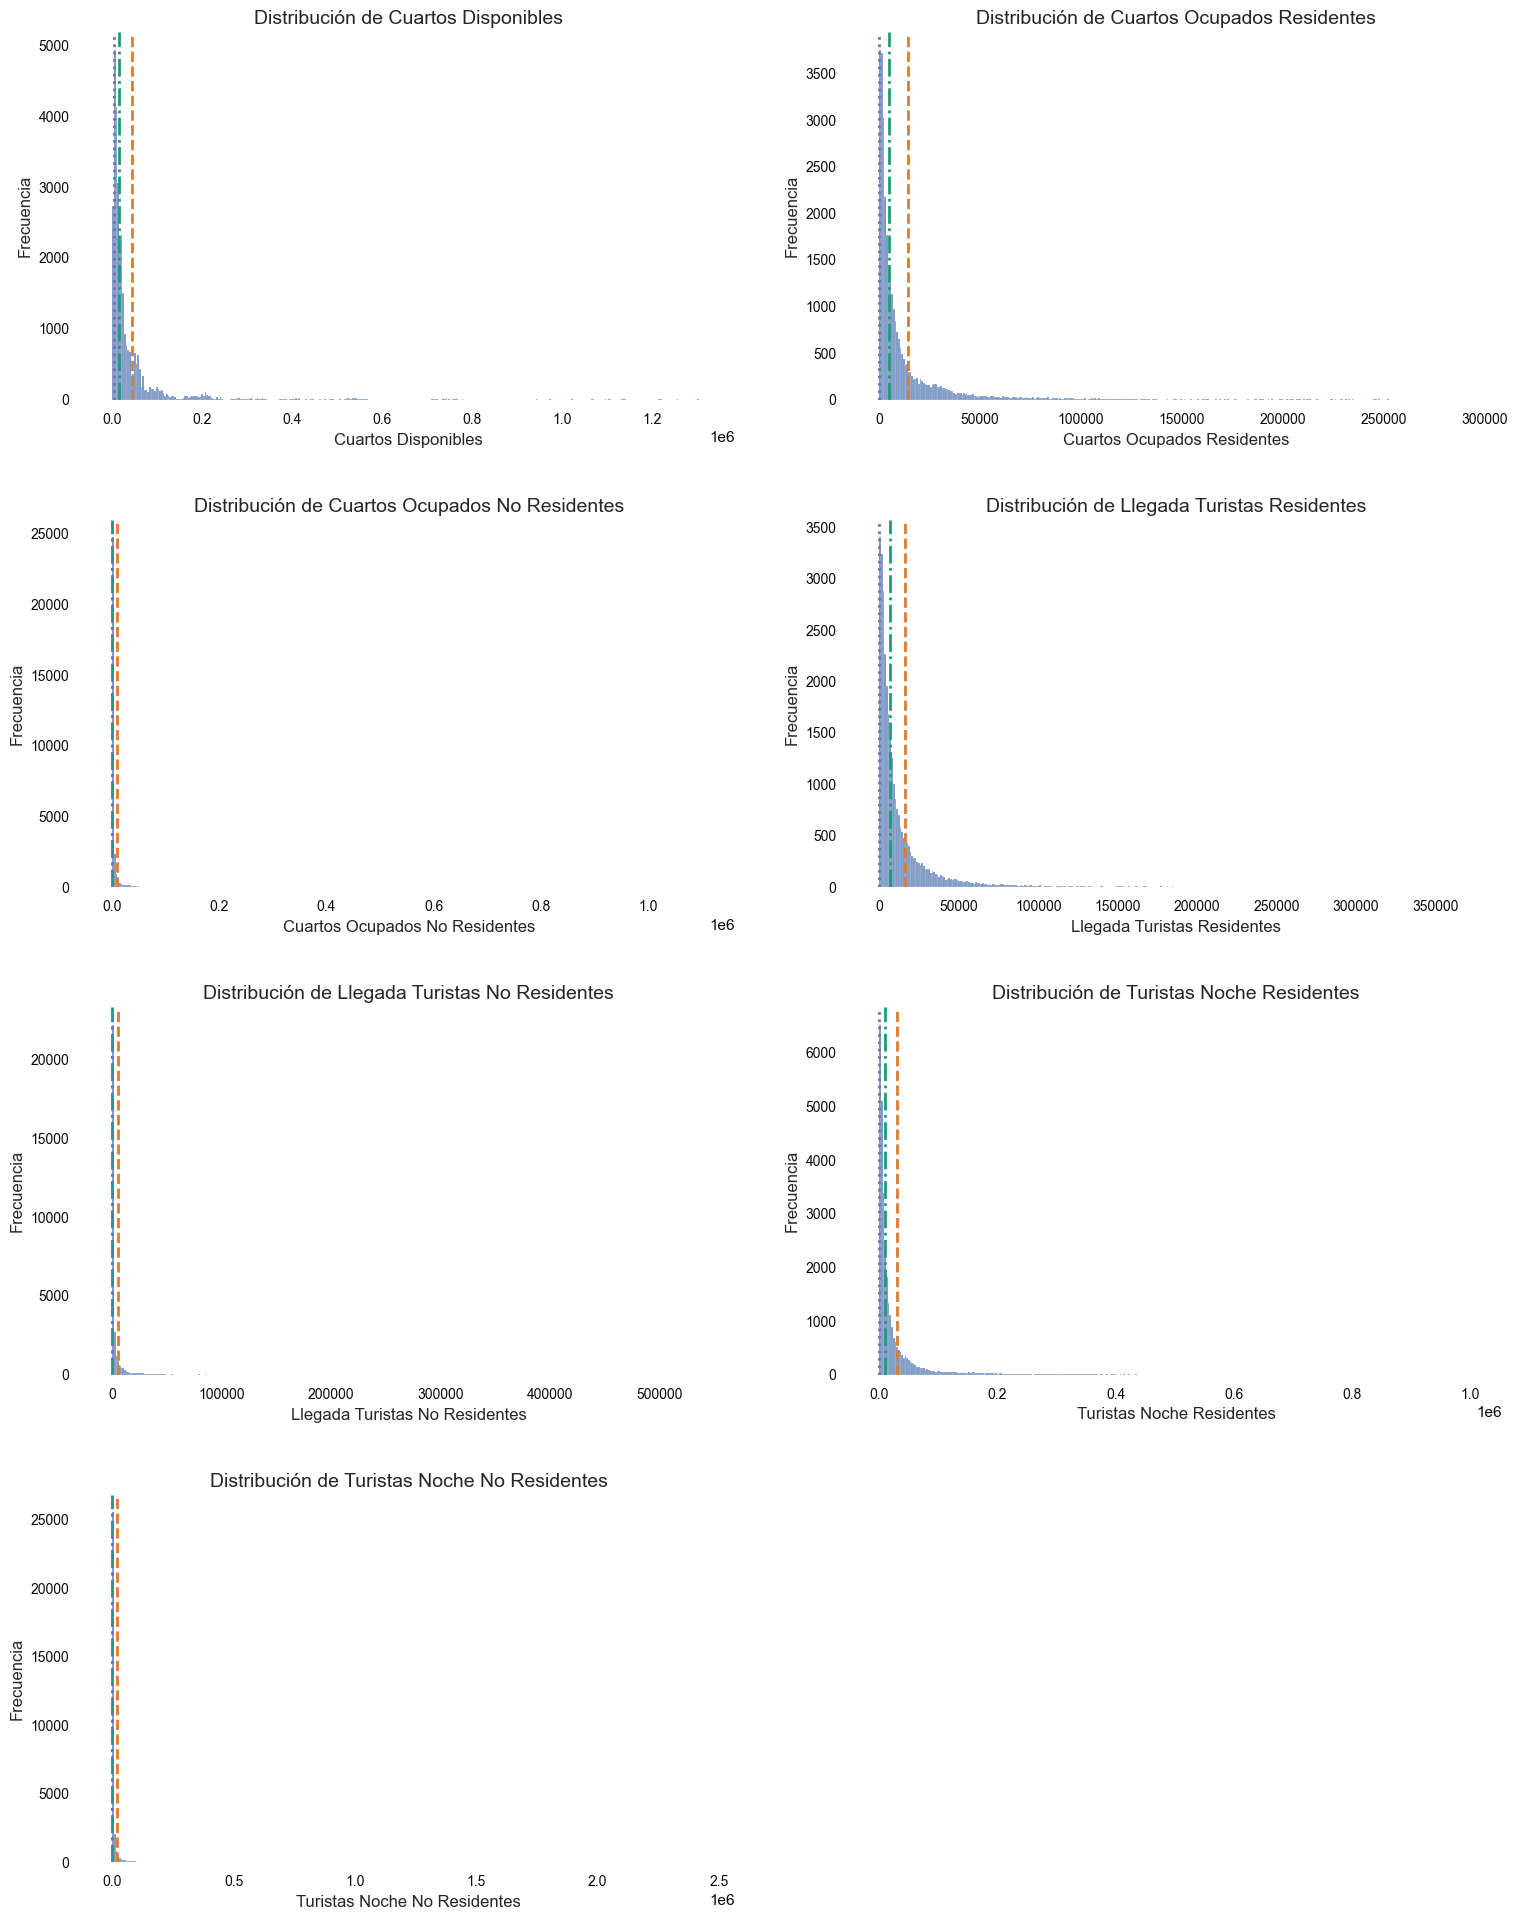

In [9]:
#Graficamos las variables numéricas para identificar su distribución y posibles outliers
def plot_columnas_numericas(df: pd.DataFrame, columnas: list):
    """Genera un único lienzo con subgráficas para las variables numéricas.
    Parámetros:
    df (pd.DataFrame): DataFrame que contiene los datos.
    columnas (list): Lista de columnas numéricas a graficar.
    """
    #Configuración estética de los gráficos
    sns.set_theme(style = "white")
    plt.rcParams["font.family"] = "sans-serif"

    #Calculamos las filas y columnas para le lienzo
    num_columnas_grid = 2
    num_filas_grid = math.ceil(len(columnas) / num_columnas_grid)

    #Creamos el lienzo
    fig, axes = plt.subplots(
        nrows = num_filas_grid,
        ncols = num_columnas_grid,
        figsize = (16, 5 * num_filas_grid)
    )

    #Iteramos sobre las columnas y los ejes para graficar
    axes = axes.flatten()  # Aplanamos los ejes para iterar fácilmente

    for idx, col in enumerate(columnas):
        ax = axes[idx]


        #Calculamos las MTC
        media = df_turismo_clean[col].mean()
        mediana = df_turismo_clean[col].median()
        moda = df_turismo_clean[col].mode().iloc[0]

        #Gráfico de caja para identificar outliers
        sns.histplot(x = df[col], ax = ax, color = "#4c72b0")

        #Trazmaos nuestras mtc
        ax.axvline(x=media, color="#e07a2c", linestyle="--", linewidth=2, label=f"Media: {media:,.1f}")
        ax.axvline(x=mediana, color="#1b9e77", linestyle="-.", linewidth=2, label=f"Mediana: {mediana:,.1f}")
        ax.axvline(x=moda, color="#7570b3", linestyle=":", linewidth=2, label=f"Moda: {moda:,.1f}")

        # Configuración de títulos y etiquetas

        #Configuración de títulos y etiquetas
        ax.set_title(f'Distribución de {col.title().replace("_", " ")}', fontsize = 14)
        ax.set_xlabel(col.title().replace("_", " "), fontsize = 12)
        ax.set_ylabel("Frecuencia", fontsize = 12)
        ax.tick_params(labelsize = 10, colors = "#0A0909")

        #Removemos bordes
        sns.despine(ax = ax, left = True, bottom = True)

    #Ocultamos ejes vacíos si el número de columnas es impar
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])


    plt.tight_layout(pad = 3.0)
    plt.show()

columnas_numericas = [
    'cuartos_disponibles',
    'cuartos_ocupados_residentes',
    'cuartos_ocupados_no_residentes',
    'llegada_turistas_residentes',
    'llegada_turistas_no_residentes',
    'turistas_noche_residentes',
    'turistas_noche_no_residentes'
]

plot_columnas_numericas(df_turismo_clean, columnas_numericas)

In [10]:
#Obtenemos las medidas de forma de nuestros datos
df_formas = pd.DataFrame({
    "asimetria": df_turismo_clean[columnas_numericas].skew(),
    "kurtosis": df_turismo_clean[columnas_numericas].kurt()
})
print(df_formas)

                                asimetria    kurtosis
cuartos_disponibles              6.697961   57.937796
cuartos_ocupados_residentes      4.513566   26.275037
cuartos_ocupados_no_residentes  12.021056  168.552608
llegada_turistas_residentes      4.529155   27.004903
llegada_turistas_no_residentes  10.330913  123.840122
turistas_noche_residentes        4.496350   27.719009
turistas_noche_no_residentes    11.301272  144.764952


In [11]:
#Se calculan la cantidad de valores 0
total_ceros = pd.DataFrame({
    "total_ceros": (df_turismo_clean[columnas_numericas] == 0).sum(),
    "porcentaje_ceros %": round((df_turismo_clean[columnas_numericas] == 0).mean()* 100, 2)}
)
total_ceros

,total_ceros,porcentaje_ceros %
cuartos_disponibles,0,0.00
cuartos_ocupados_residentes,548,1.76
cuartos_ocupados_no_residentes,8997,28.89
llegada_turistas_residentes,552,1.77
llegada_turistas_no_residentes,9083,29.16
turistas_noche_residentes,548,1.76
turistas_noche_no_residentes,8997,28.89


Los datos de la asimetría y kurtosis confirman lo visualizado en los histogramas: existe un sesgo positivo (> 0) con leptokurtosis en la distribución de nuestras variables numéricas, lo que ocasiona una larga cola sesgada a la derecha. Con esto podemos decir que: 
* Se prefiere usar la mediana como medida para cálculos estadísticos.
* El sesgo es resultado de la naturaleza de los datos, ya que existen observaciones que tenderán a tener mayor registro de habitaciones, noches y residentes, por lo que se opta por no ponderar ni imputar valores para no alterar los datos.
* Para modelados es necesario usar log1p, normalizaciones o segmentaciones para manejar las variables sesgadas.
* El sesgo es un hallazgo: hay percentiles que concentran la demanda turísticas.

### Exploración de datos: identificación de relaciones y patrones en nuestros datos.

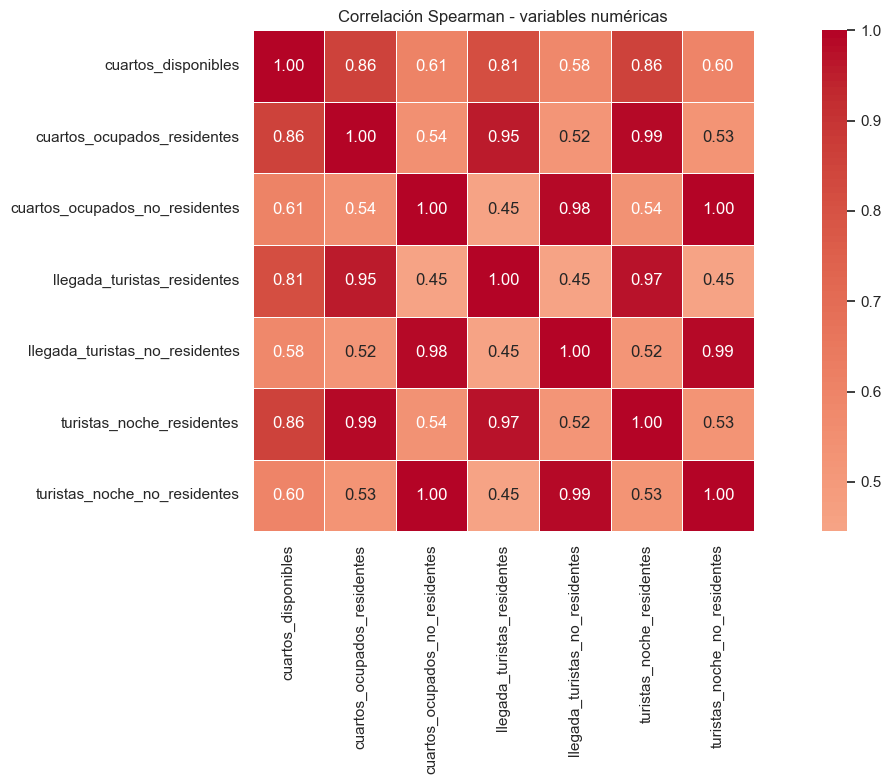

In [12]:
#Correlación de varaibles numéricas
corr = df_turismo_clean[columnas_numericas].corr(method = "spearman")

#Graficamos un heatmap con los datos de nuestra correlación
plt.figure(figsize=(14,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=.5)
plt.title("Correlación Spearman - variables numéricas")
plt.tight_layout()
plt.show()

Se emplea correlación de spearman por lo siguiente:
* Pearson supone normalidad, dado que es susceptible a valores atípicos. Bajo este caso, con distribuciones sesgados, Spearman es más robusto al basarse en rangos.
* Spearman mide relaciones monótonas: cuando una variable aumenta, la otra también, pero no necesariamente a un ritmo lineal o constante.

Nota: el análisis de correlaciones se realiza solamente entre variables cuantitativas continuas. El empleo de variables cualitativas en este tipo de análisis debe ser muy cuidadoso, ya que codificar arbitrariamente estas variables induce a errores. También hay que reservar la inclusión de variables cualitativas ordinales para aquellas cuyos intervalos sean iguales, razón que no se cumple en la variable categoria (estrellas de hotel).
Para análisis de variables categóricas se prefiere ANOVA, Kruskal Willis. Chi cuadrado o Crammers's V.


**Precauciones:**
Aunque el coeficiente de correlación es alto (>0.5), el rango mayor a 0.8 alerta sobre una posible multicolinealidad entre las variables, ya que algunas de ellas son redundantes (explican el mismo fenómeno). Por ejemplo, las variables cuartos disponibles, cuartos ocupados y llegadas tienen como variable subyacente la infraestructura turísta que define la oferta hotelera, lo que implica que a mayor oferta de cuartos disponibles, las llegadas y ocupaciones también serán mayores, ergo, la escala tienda a subir en lugares donde la oferta se ha estructurado para alojar una demanada alta.

En lugar de ocupar los valores absolutos de las variables, se construyen tasas e índices para una mejor interpretación de los datos.

In [13]:
# Porcentaje de ocupación: cociente de cuartos disponibles entre total de cuartos ocupados (nacional e internacional)
df_turismo_clean['ocupacion_total'] = (df_turismo_clean["cuartos_ocupados_residentes"] + df_turismo_clean["cuartos_ocupados_no_residentes"])
df_turismo_clean['porcentaje_ocupacion_total'] = (df_turismo_clean['cuartos_ocupados_residentes'] + df_turismo_clean['cuartos_ocupados_no_residentes']) / df_turismo_clean['cuartos_disponibles'] * 100

# Estadía promedio: número de noches que se hospedaron los huéspedes entre el número de llegadas (por tipo de residente) 
df_turismo_clean['estadia_residentes'] = df_turismo_clean['turistas_noche_residentes'] / df_turismo_clean['llegada_turistas_residentes']
df_turismo_clean['estadia_no_residentes'] = df_turismo_clean['turistas_noche_no_residentes'] / df_turismo_clean['llegada_turistas_no_residentes']

# Densidad: oferta de cuartos por turista entre total de llegadas
df_turismo_clean['cuartos_por_turista'] = df_turismo_clean['cuartos_disponibles'] / (df_turismo_clean['llegada_turistas_residentes'] + df_turismo_clean['llegada_turistas_no_residentes'])

# Mix internacional: del total de llegadas, ¿qué porcentaje fue de personas extranjeras?
df_turismo_clean['mix_internacional'] = df_turismo_clean['llegada_turistas_no_residentes'] / (df_turismo_clean['llegada_turistas_residentes'] + df_turismo_clean['llegada_turistas_no_residentes'])

# Limpieza de infinitos por división entre 0
df_turismo_clean.replace([np.inf, -np.inf], np.nan, inplace=True)



Los cálculos anteriores tienen una particularidad: arrojan missing values cuando se divide entre 0. Dejarlos como tal tipo de datos se fundamenta en que un ratio nulo indica que no se puede determinar la proporción de, digámoslo, la ocupación de los cuartos. Siendo 0 un dato real que indica un conteo cero de residentes, la tasa no puede ser calculada bajo esa razón. 
Por lo tanto, el uso de las tasas en test y modelados se debe tener tomando en cuenta estos valores faltante (algunas funciones de agregación los ignoran en automático o podemos dropearlos directamente).

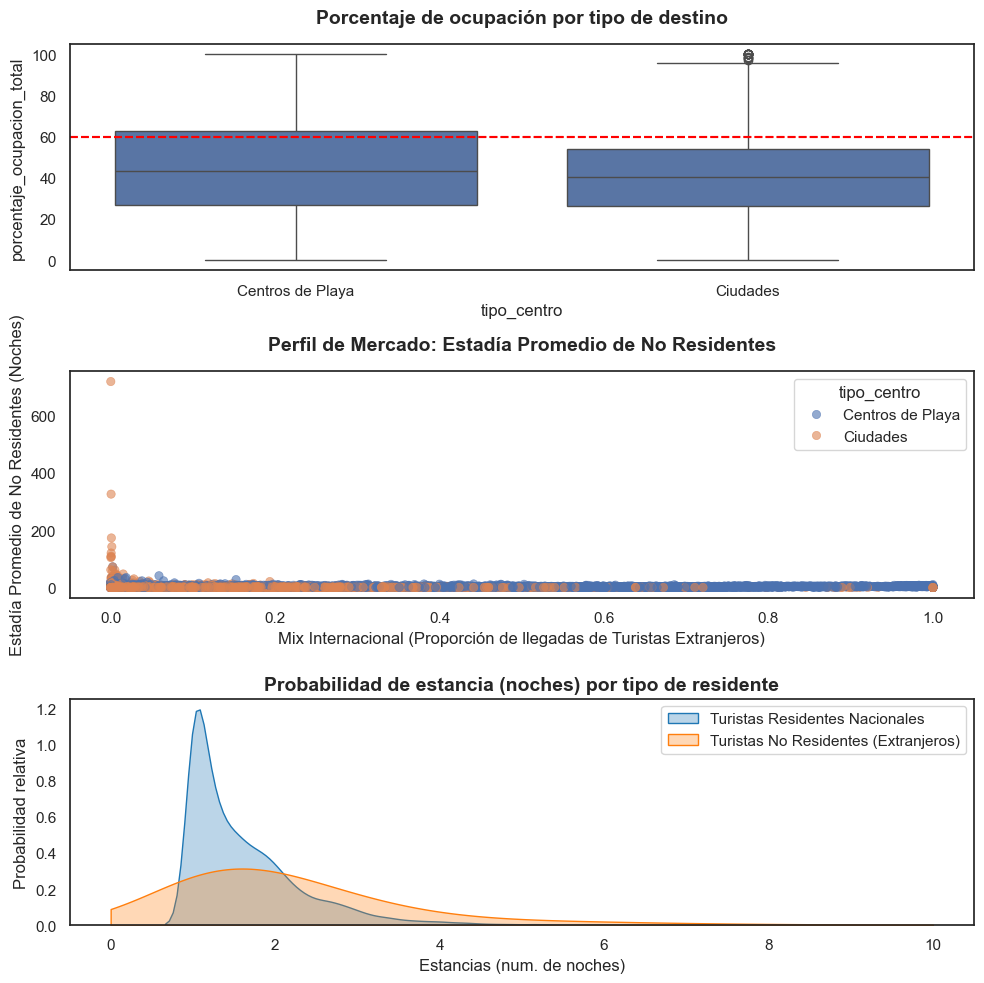

In [14]:
# Exploramos nuestros ratios con gráficas
fg, axes = plt.subplots(nrows = 3, ncols = 1, figsize = (10,10), sharex = False)
ax = axes.flatten() #Aplanamos la cuadrícula

# Histograma Porcentaje de ocupación por tipo de destino
sns.boxplot(data=df_turismo_clean, x='tipo_centro', y='porcentaje_ocupacion_total', ax= ax[0])
ax[0].set_title('Ocupación % por Tipo de Destino')
ax[0].axhline(60, color='red', linestyle='--', label='Punto equilibrio')
ax[0].set_title('Porcentaje de ocupación por tipo de destino', fontsize = 14, pad = 15, fontweight = "bold")
ax[0].axhline(60, color='red', linestyle='--', label='Punto equilibrio')

#Clusters Nacional/Internacional... ¿quién se hospeda por más tiempo?
sns.scatterplot(data = df_turismo_clean, 
                x= "mix_internacional", 
                y = "estadia_no_residentes", 
                hue= "tipo_centro", 
                ax = ax[1],
                alpha = 0.6, 
                palette = "deep", 
                edgecolor = None, 
                )
ax[1].set_title('Perfil de Mercado: Estadía Promedio de No Residentes', fontsize=14, pad=15, fontweight='bold')
ax[1].set_xlabel('Mix Internacional (Proporción de llegadas de Turistas Extranjeros)', fontsize=12)
ax[1].set_ylabel('Estadía Promedio de No Residentes (Noches)', fontsize=12)

#Estadía promedio (num. noches) por condición de residencia
sns.kdeplot(
    data = df_turismo_clean,
    x = "estadia_residentes",
    label = "Turistas Residentes Nacionales",
    ax = ax[2],
    fill = True,
    alpha = 0.3,
    color = "#1F77B4",
    clip = (0,10)
)
sns.kdeplot(
    data = df_turismo_clean,
    x = "estadia_no_residentes",
    label = "Turistas No Residentes (Extranjeros)",
    ax = ax[2],
    fill = True,
    alpha = 0.3,
    color='#FF7F0E',
    clip = (0,10)
)
ax[2].set_title("Probabilidad de estancia (noches) por tipo de residente", fontsize = 14, fontweight = "semibold")
ax[2].legend(loc = "upper right")
ax[2].set_xlabel("Estancias (num. de noches)")
ax[2].set_ylabel("Probabilidad relativa")

plt.tight_layout()
plt.show()


De forma exploratotia se presentan tres características generales del dataset:
* Porcentaje de ocupación por tipo de destino:
    * Presenta una mediana inferior al umbral mínimo de RevPAR (Revenue Per Available Room)*.
    * Las ciudades presentan una tasa de ocupación más concentrada cerca de su mediana, pero también contiene outliers con tasas que rondan el 100%.
    * Los centros de playa, en general, presentan una tasa mayor de ocupación.
    * Al ser datos generales, es necesario desagregarlos y analizarlos en series de tiempo para entender cómo esos cuartiles varían por temporadas y regiones.
* Información relevante de estancia promedio de No Residentes:
    * Existencia de picos (aprox. 700) en las noches de estancia para una proporción menor de turistas extranjeros en ciudades. 
    * Las demás observaciones se centran en estadías más cortas.
*  Probabilidad de estancia (noches):
    * Alta probabilidad de que turistas nacionales tenga una estadía corta (entre 1 y 3 noches).
    * Los turistas no residentes tienen una mayor probabilidad de permancer más de 3 noches.

*https://www.finmodelbuilder.com/blog/hotel-break-even-analysis.html

Síntesis:
Resultado de una exploración general, podemos decir que la industria turísca se marca por las siguientes cuestiones:
* Una ocupación presuntamente baja en comparación con un umbral mínimo para cobertura de gastos de infraesctura, mantenimiento y gastos operativos.
* Estancias cortas con un grupo de permanencia prolongado (turismo no residente en ciudades, principalmente).
* turismo residente de paso y un turismo no residente con mayor estancia.

## Análisis estadístico y modelado
A continuación realizaremos un análisis profundo de los datos, haciendo uso de un enfoque regional, pruebas de hipótesis, test estadísticos y modelado algorítmo para responder a preguntas precisas sobre el turismo en Oaxaca.

In [35]:
#Como primer paso, seleccionamos los centros turísticos pertenencientes a Oaxaca.
#Volvemos a limpiar los espacios en los registros de "centro"
df_turismo_clean['centro'] = df_turismo_clean['centro'].astype(str).str.strip()
centros_oaxaca = ["Oaxaca", "Puerto Escondido", "Bahías de Huatulco"]
df_turismo_oaxaca = df_turismo_clean[df_turismo_clean["centro"].isin(centros_oaxaca)]
df_turismo_oaxaca.head()

,año,mes,tipo_centro,subtipo_centro,centro,categoria,cuartos_disponibles,cuartos_ocupados_no_residentes,cuartos_ocupados_residentes,llegada_turistas_no_residentes,llegada_turistas_residentes,turistas_noche_no_residentes,turistas_noche_residentes,fecha,ocupacion_total,porcentaje_ocupacion_total,estadia_residentes,estadia_no_residentes,cuartos_por_turista,mix_internacional
3,2016,1,Centros de Playa,Integralmente Planeados,Bahías de Huatulco,2 estrellas,5549,0,2571,0,4816,0,6320.0,2016-01-01,2571,46.332673,1.312292,NaN,1.152201,0.000000
4,2016,1,Centros de Playa,Integralmente Planeados,Bahías de Huatulco,3 estrellas,12896,0,4360,0,8560,0,11464.0,2016-01-01,4360,33.808933,1.339252,NaN,1.506542,0.000000
5,2016,1,Centros de Playa,Integralmente Planeados,Bahías de Huatulco,4 estrellas,31558,8721,15803,1740,11432,17381,35019.0,2016-01-01,24524,77.710882,3.063244,9.989080,2.395840,0.132098
6,2016,1,Centros de Playa,Integralmente Planeados,Bahías de Huatulco,5 estrellas,63147,35379,19475,6495,8823,73091,42849.0,2016-01-01,54854,86.867151,4.856511,11.253426,4.122405,0.424011
34,2016,1,Centros de Playa,Otros,Puerto Escondido,1 estrella,9579,413,2909,413,4911,924,7345.0,2016-01-01,3322,34.680029,1.495622,2.237288,1.799211,0.077573


In [36]:
df_turismo_oaxaca.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1512 entries, 3 to 31041
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   año                             1512 non-null   int64         
 1   mes                             1512 non-null   int64         
 2   tipo_centro                     1512 non-null   category      
 3   subtipo_centro                  1512 non-null   category      
 4   centro                          1512 non-null   object        
 5   categoria                       1512 non-null   category      
 6   cuartos_disponibles             1512 non-null   int64         
 7   cuartos_ocupados_no_residentes  1512 non-null   int64         
 8   cuartos_ocupados_residentes     1512 non-null   int64         
 9   llegada_turistas_no_residentes  1512 non-null   int64         
 10  llegada_turistas_residentes     1512 non-null   int64         
 11  turistas

Variables categóricas y numéricas

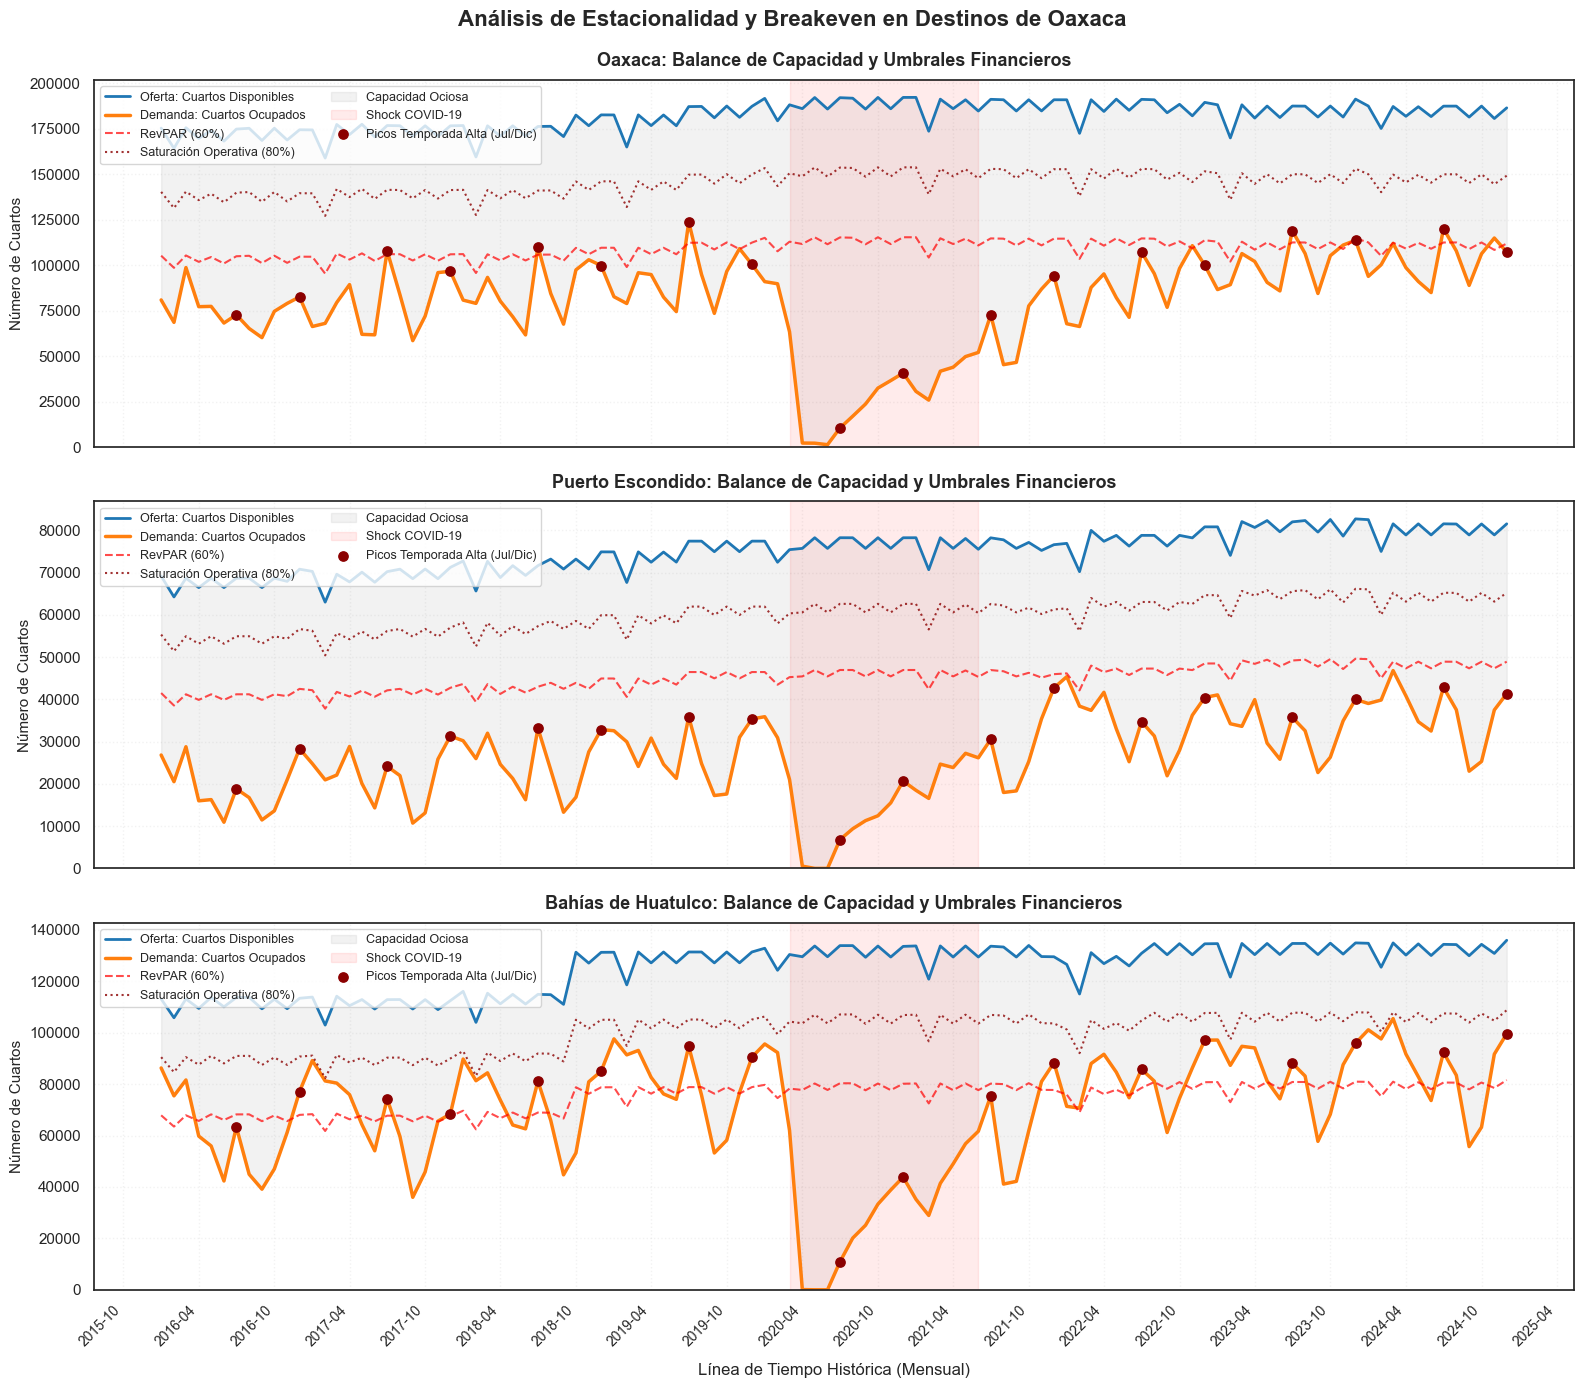

In [37]:
"""
Hacemos la suma de los valores de las variables cuartos disponibles y ocupación total.
Esto se hacer porque la capcidad total del destino por fecha es la suma de la oferta de todas las categorías (estrellas).
"""
totales_por_centro = df_turismo_oaxaca.groupby(['centro', 'fecha']).agg({
    'cuartos_disponibles': 'sum',
    'ocupacion_total': 'sum'
}).reset_index()

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 14), sharex=True)

for idx, centro in enumerate(centros_oaxaca):
    ax = axes[idx]
    data = totales_por_centro[totales_por_centro['centro'] == centro].sort_values('fecha')
    
    # --- CÁLCULO DE UMBRALES DINÁMICOS (Volumen en función de la capacidad) ---
    # Punto de Equilibrio Financiero (60% de la oferta)
    umbrales_60 = data['cuartos_disponibles'] * 0.60
    # Límite de Saturación Operativa (80% de la oferta)
    umbrales_80 = data['cuartos_disponibles'] * 0.80
    
    # --- GRAFICACIÓN DE SERIES PRINCIPALES ---
    ax.plot(data['fecha'], data['cuartos_disponibles'],
            color='#1f77b4', linewidth=2, label='Oferta: Cuartos Disponibles')
    
    ax.plot(data['fecha'], data['ocupacion_total'],
            color='#ff7f0e', linewidth=2.5, label='Demanda: Cuartos Ocupados')
    
    # --- GRAFICACIÓN DE UMBRALES ---
    ax.plot(data['fecha'], umbrales_60, color='red', linestyle='--', 
            alpha=0.7, label='RevPAR (60%)')
    ax.plot(data['fecha'], umbrales_80, color='darkred', linestyle=':', 
            alpha=0.8, label='Saturación Operativa (80%)')
    
    # --- ÁREAS DE CONTROL ---
    # Capacidad Ociosa (Entre Oferta Total y Demanda Real)
    ax.fill_between(data['fecha'], data['cuartos_disponibles'], data['ocupacion_total'],
                    where=(data['cuartos_disponibles'] >= data['ocupacion_total']),
                    interpolate=True, color='gray', alpha=0.1, label='Capacidad Ociosa')
    
    # Sombreado de Shocks Exteriores: Periodo COVID-19
    ax.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-06-01'),
               color='red', alpha=0.08, label='Shock COVID-19')
    
    # --- DESTACAR ESTACIONALIDAD (Picos de Julio y Diciembre) ---
    # Filtramos los meses de alta temporada para poner marcadores visuales
    picos_alta = data[data['fecha'].dt.month.isin([7, 12])]
    ax.scatter(picos_alta['fecha'], picos_alta['ocupacion_total'], 
               color='darkred', s=45, zorder=5, label='Picos Temporada Alta (Jul/Dic)')
    
    # --- FORMATEO ESTÉTICO ---
    ax.set_title(f'{centro}: Balance de Capacidad y Umbrales Financieros', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Número de Cuartos', fontsize=11)
    ax.legend(loc='upper left', fontsize=9, ncol=2) # ncol=2 distribuye mejor las etiquetas
    ax.grid(True, alpha=0.25, linestyle=':')
    ax.set_ylim(bottom=0)

# --- CONFIGURACIÓN DEL EJE X (Aplicado al último subplot compartido) ---
# Mostramos etiquetas cada 6 meses indicando Año-Mes de forma legible
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, ha='right', fontsize=10)
axes[-1].set_xlabel('Línea de Tiempo Histórica (Mensual)', fontsize=12, labelpad=10)

plt.suptitle('Análisis de Estacionalidad y Breakeven en Destinos de Oaxaca', fontsize=16, y=0.99, fontweight='bold')
plt.tight_layout()
plt.show()

En términos de ocupación, ¿cómo se representa el panorama Oaxaqueño? 
El umbral 60%, como se dijo, representa el RevPAR, o ingreso por habitación disponible, nos marca en qué porcentaje de ocupación deben alcanzar los negocios de hospedajes para poder cubrir los gastos de funcionamiento. 
El umbral 80%, por su parte, indica una sobreocupación: capacidad de demanda alta que puede indicar un posible sector de expansión de negocios turísticos. 
A continuación se cuantifican estos umbrales para cada centro de Oaxaca.

In [38]:
# Meses rentables vs meses en pérdida por centro
for centro in centros_oaxaca:
    data = totales_por_centro[totales_por_centro['centro'] == centro].copy()
    data['ocupacion_pct'] = data['ocupacion_total'] / data['cuartos_disponibles'] * 100
    
    meses_equilibrio = (data['ocupacion_pct'] >= 60).sum()
    meses_saturacion = (data['ocupacion_pct'] >= 80).sum()
    meses_perdida = (data['ocupacion_pct'] < 60).sum()
    total_meses = len(data)
    
    print(f"{centro}:")
    print(f"  RevPAR >60%: {meses_equilibrio}/{total_meses} meses ({meses_equilibrio/total_meses*100:.0f}%)")
    print(f"  Saturación >80%: {meses_saturacion}/{total_meses} meses")
    print(f"  Pérdida <60%: {meses_perdida}/{total_meses} meses\n")

Oaxaca:
  RevPAR >60%: 9/108 meses (8%)
  Saturación >80%: 0/108 meses
  Pérdida <60%: 99/108 meses

Puerto Escondido:
  RevPAR >60%: 0/108 meses (0%)
  Saturación >80%: 0/108 meses
  Pérdida <60%: 108/108 meses

Bahías de Huatulco:
  RevPAR >60%: 55/108 meses (51%)
  Saturación >80%: 0/108 meses
  Pérdida <60%: 53/108 meses



huatulco sobresale por su alta tasa de RevPar, teniendo 51% de meses por arriba de este umbral. En cambio, Oaxaca y Puerto Escondido fluctuan en porcentajes inferiores. 
Para profundizar en el tema s eobservará el comportamiento de ocupación por categoría de los hoteles, teniendo 5 clasificaciones: 1 estrella, 2 estrellas, 3 estrellas, 4 estrellas y 5 estrellas.

In [31]:
# Agrupamos por categoría hotelera para consolidar el volumen total histórico
ocupacion_categoria = df_turismo_oaxaca.groupby(['categoria'], observed=True).agg({
    'cuartos_disponibles': 'sum',
    'ocupacion_total': 'sum'
}).reset_index()

# Ordenamos de mayor a menor infraestructura para facilitar la lectura visual
ocupacion_categoria = ocupacion_categoria.sort_values('cuartos_disponibles', ascending=False)

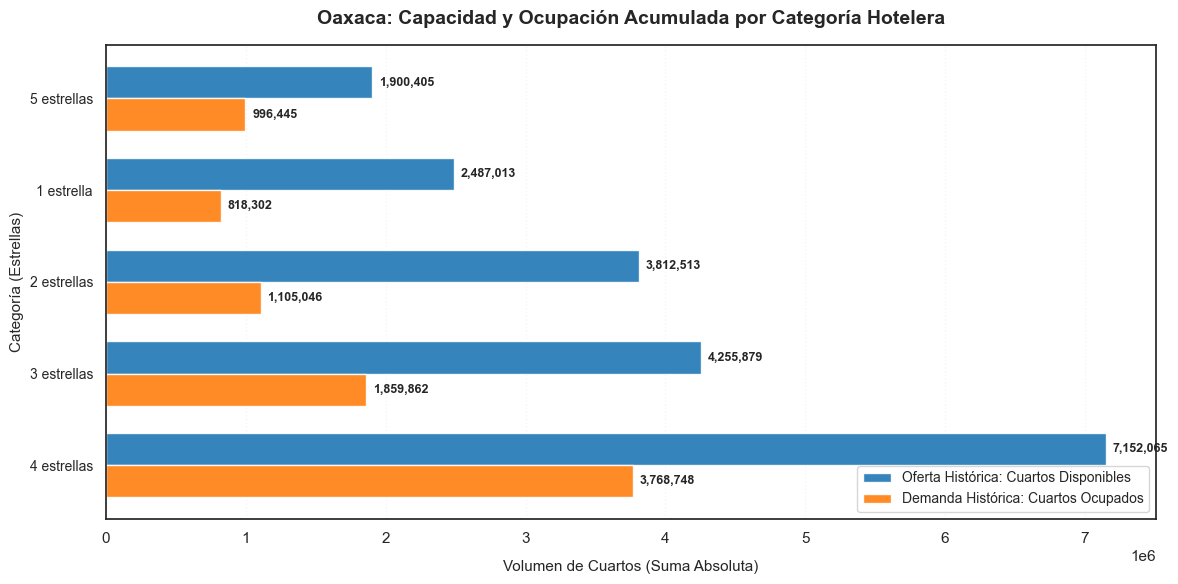

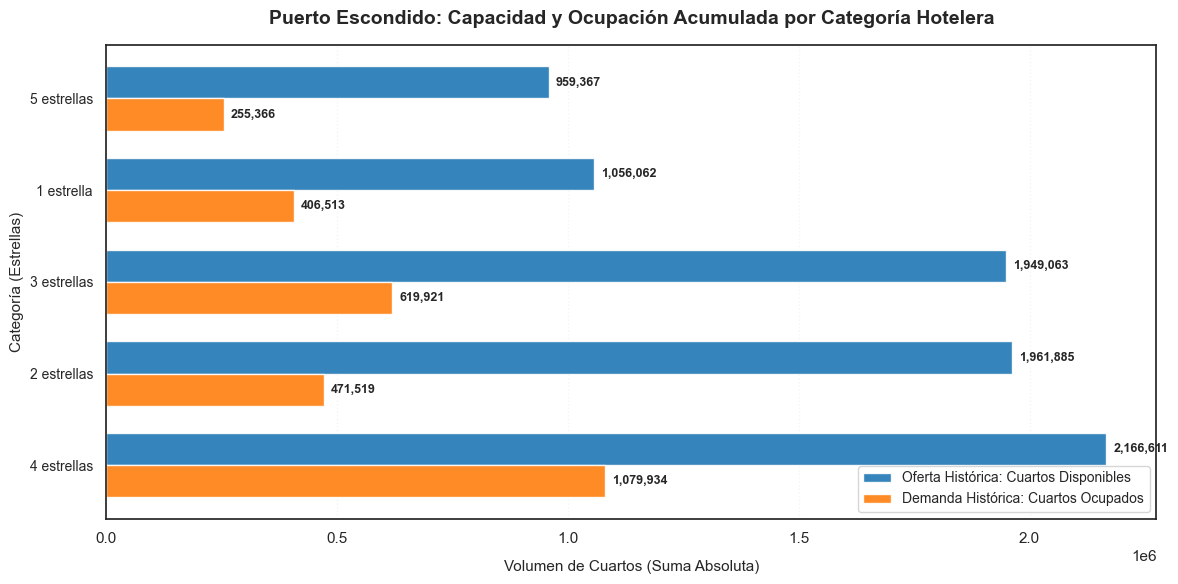

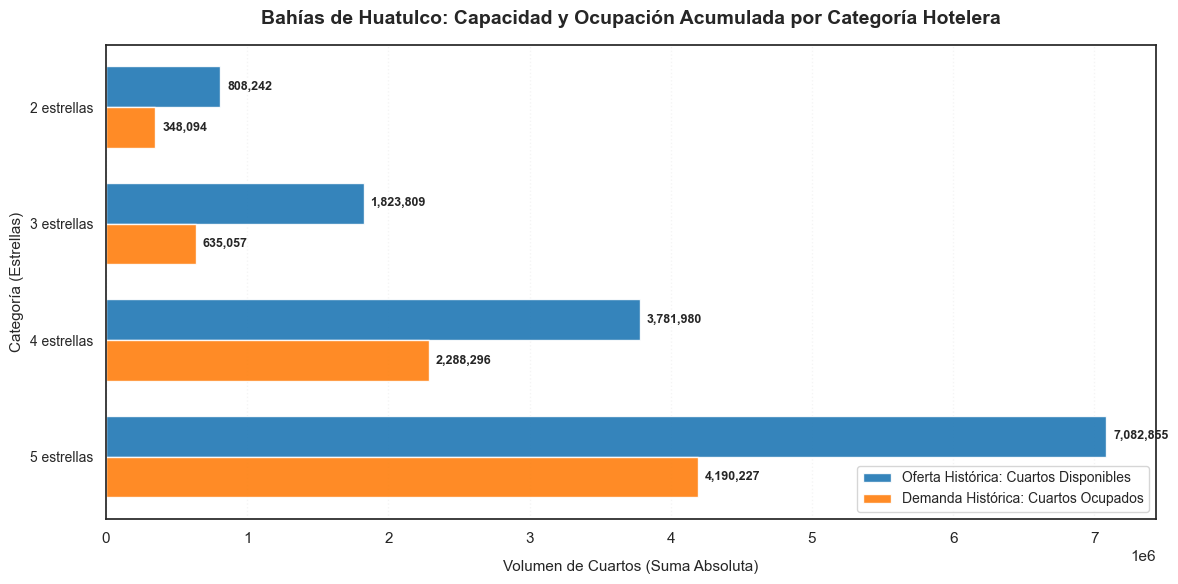

In [32]:
import matplotlib.pyplot as plt
import numpy as np

centros = ["Oaxaca", "Puerto Escondido", "Bahías de Huatulco"]

for centro in centros:
    # 1. Filtramos y agrupamos usando la variable local de forma correcta con observed=True
    df_centro_cat = df_turismo_oaxaca[df_turismo_oaxaca['centro'] == centro].groupby(['categoria'], observed=True).agg({
        'cuartos_disponibles': 'sum',
        'ocupacion_total': 'sum'
    }).reset_index()
    
    df_centro_cat = df_centro_cat.sort_values('cuartos_disponibles', ascending=False)
    df_centro_cat = df_centro_cat[df_centro_cat['cuartos_disponibles'] > 0]
    
    labels = df_centro_cat['categoria'].astype(str)
    y = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # CORRECCIÓN AQUÍ: Cambiamos 'ocupacion_categoria' por 'df_centro_cat'
    rects1 = ax.barh(y + width/2, df_centro_cat['cuartos_disponibles'], width, 
                     label='Oferta Histórica: Cuartos Disponibles', color='#1f77b4', alpha=0.9)
    
    rects2 = ax.barh(y - width/2, df_centro_cat['ocupacion_total'], width, 
                     label='Demanda Histórica: Cuartos Ocupados', color='#ff7f0e', alpha=0.9)
    
    # --- FORMATEO ESTÉCO ---
    ax.set_title(f'{centro}: Capacidad y Ocupación Acumulada por Categoría Hotelera', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Volumen de Cuartos (Suma Absoluta)', fontsize=11, labelpad=10)
    ax.set_ylabel('Categoría (Estrellas)', fontsize=11)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, axis='x', alpha=0.2, linestyle=':')
    ax.set_xlim(left=0)
    
    # Agregamos etiquetas de datos dinámicas basadas en los datos reales del centro
    for rect in rects1:
        width_val = rect.get_width()
        if width_val > 0:
            ax.annotate(f'{width_val:,.0f}',
                        xy=(width_val, rect.get_y() + rect.get_height() / 2),
                        xytext=(5, 0), textcoords="offset points",
                        ha='left', va='center', fontsize=9, fontweight='semibold')
            
    for rect in rects2:
        width_val = rect.get_width()
        if width_val > 0:
            ax.annotate(f'{width_val:,.0f}',
                        xy=(width_val, rect.get_y() + rect.get_height() / 2),
                        xytext=(5, 0), textcoords="offset points",
                        ha='left', va='center', fontsize=9, fontweight='semibold')
            
    plt.tight_layout()
    plt.show()

Comentarios e interpretación:
El desglose de la disponibilidad y ocupación de cuartos en Oaxaca por categoría de hotel indica la concentración de turismo de lujo en zonas como Bahía de Huatulco, centrado en hoteles de 5 y 4 estrellas. en cambio, Oaxaca y Puerto Escondido presenta un turismo mixto entre hoteles de 3,4 y 2 estrellas. 
Complementando la gráfica anterior sobre la oferta histórica de estos centros turístico, se refleja el efecto de los umbrales de demanda, siendo que en cada categoría encontramos ocupaciones que difícilmente superan el umbral del 60%.

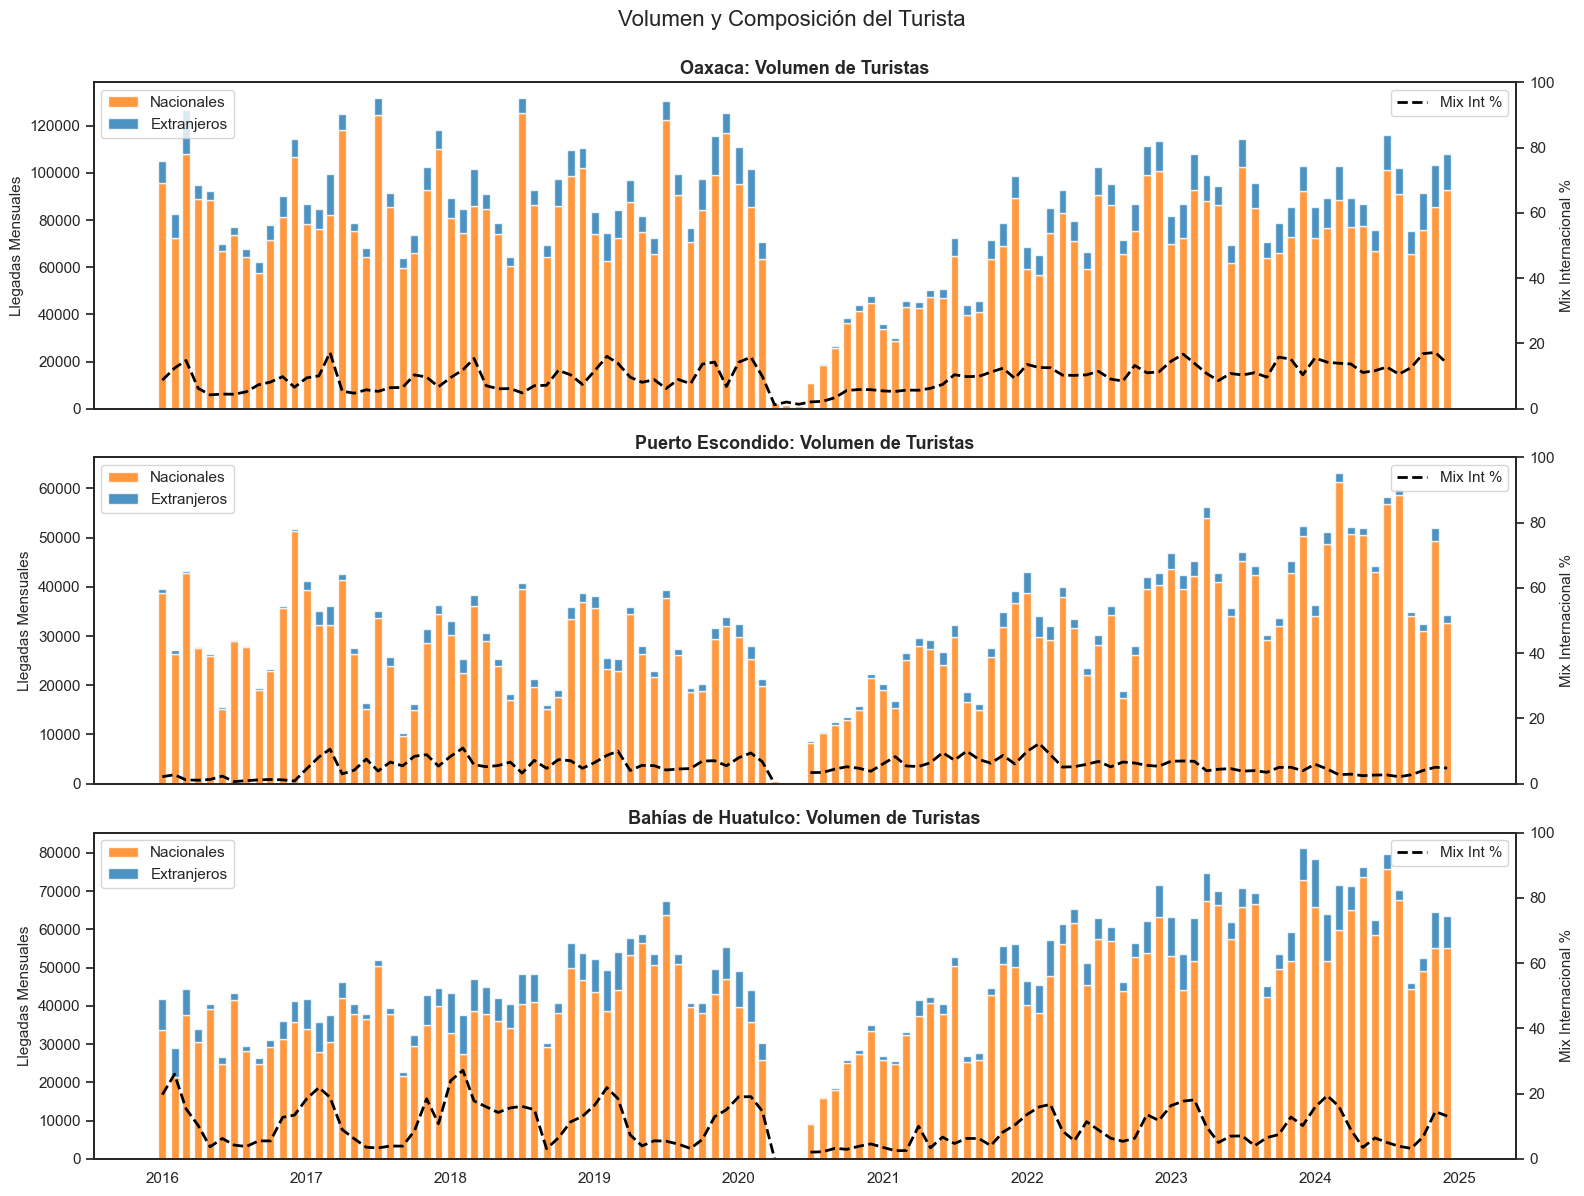

In [33]:
df_mix = df_turismo_oaxaca.groupby(['centro', 'fecha']).agg({
    'llegada_turistas_residentes': 'sum',
    'llegada_turistas_no_residentes': 'sum'
}).reset_index()

df_mix['mix_internacional'] = df_mix['llegada_turistas_no_residentes'] / (df_mix['llegada_turistas_residentes']  + df_mix["llegada_turistas_no_residentes"]) * 100


fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 12), sharex=True)

for idx, centro in enumerate(centros):
    ax1 = axes[idx]
    data = df_mix[df_mix['centro'] == centro].sort_values('fecha')

    # Barras apiladas de volumen
    ax1.bar(data['fecha'], data['llegada_turistas_residentes'], 
            width=20, color='#ff7f0e', alpha=0.8, label='Nacionales')
    ax1.bar(data['fecha'], data['llegada_turistas_no_residentes'],
            bottom=data['llegada_turistas_residentes'],
            width=20, color='#1f77b4', alpha=0.8, label='Extranjeros')
    
    ax1.set_ylabel('Llegadas Mensuales', fontsize=11)
    ax1.legend(loc='upper left')
    ax1.set_title(f'{centro}: Volumen de Turistas', fontsize=13, fontweight='bold')

    # Eje 2: línea de mix %
    ax2 = ax1.twinx()
    ax2.plot(data['fecha'], data['mix_internacional'], 
             color='black', linewidth=2, linestyle='--', label='Mix Int %')
    ax2.set_ylabel('Mix Internacional %', fontsize=11)
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper right')

plt.suptitle('Volumen y Composición del Turista', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

Las gráficas anteriores presentan la distribución de llegadas por mes-año y tipo de llegada. Esto revela una concentración de turismo nacional en los centros Oaxaqueños, con una proporción pequeña de turismo extranjero.

In [34]:
df_turismo_oaxaca["centro"].value_counts()

centro
Puerto Escondido      540
Oaxaca                540
Bahías de Huatulco    432
Name: count, dtype: int64

**Conclusiones preliminares:**
El análisis de los datos de turismo en México presenta un panorama difícil para la industria hotelera, ya que difícilmente se consigue alcanzar el umbral de retorno y gastos operativos.
Esto es particularmente cierto para el caso de Oaxaca, ya que presenta dificultadas para mantener para alcanzar este umbral. El caso de Huatulco es, en este aspecto, sobresaliente, ya que ha conseguido mantener y sobrepasar este umbral. Su particularidad se centra en los servicios de lujo de alta ocupación, con categorías de 5 y 4 estrellas con una demanda estable y redituable.
Se puede decir que el panorama turístico de Oaxaca, visto desde este análisis con este dataset oficial, es crudo y pedregoso para Oaxaca, aunque ya se haya recuperado de la caída de la pandemia, la demanda sigue siendo insuficiente para cubrir la oferta turística.
Sin embargo, también hay que contemplar los límites del estudio y de los datos. Para el caso oaxaqueño, se cuenta con un aproximado de 540 registros por centro turístico para los 9 años que contempla el dataset, restringidos a aquellos hoteles contemplados dentro de la clasificación en rangos de estrellas, por lo que es probable que otras formas de hospedaje como hostales, airbnb, departamentos o cuartos queden fuera de este análisis. Por ello, sería necesario complementar con otras bases de datos para mejorar la calidad del análisis.
Sumado a ello, los datos de la época de covid pueden causar errores de interpretación, porque se presentan como ausencia de registro y de muy baja operación, siendo que esto se puede deber, en parte, a la incapacidad de emplear métodos de captación de información por parte de las secretarías y no por la clausura de operaciones en hoteles, ya que es sabido que gran parte de la industria siguió operando bajo medidas sanitarias cautelares, sin llegar a emplearse un cierra total del sector.
Una cuestión es el contraste entre crecimiento urbano y de infraestructura turística con el registro en la SECTUR de hoteles en función, ya que muchos centros turísticos, particularmente Puerto Escondido, están en auge de crecimiento, el cual no necesariamente se expresa de forma exacta en los registros de la SECTUR.
Finalmente, es necesario cuestionarse sobre cómo el sector turístico hotelero parece presentarse como un sector frágil, en cuanto a que difícilmente se logra alcanzar el umbra RevPAR. En cambio, los reportes e informes nacionales reportan que el sector turístico es uno de los más potentes en México.  
